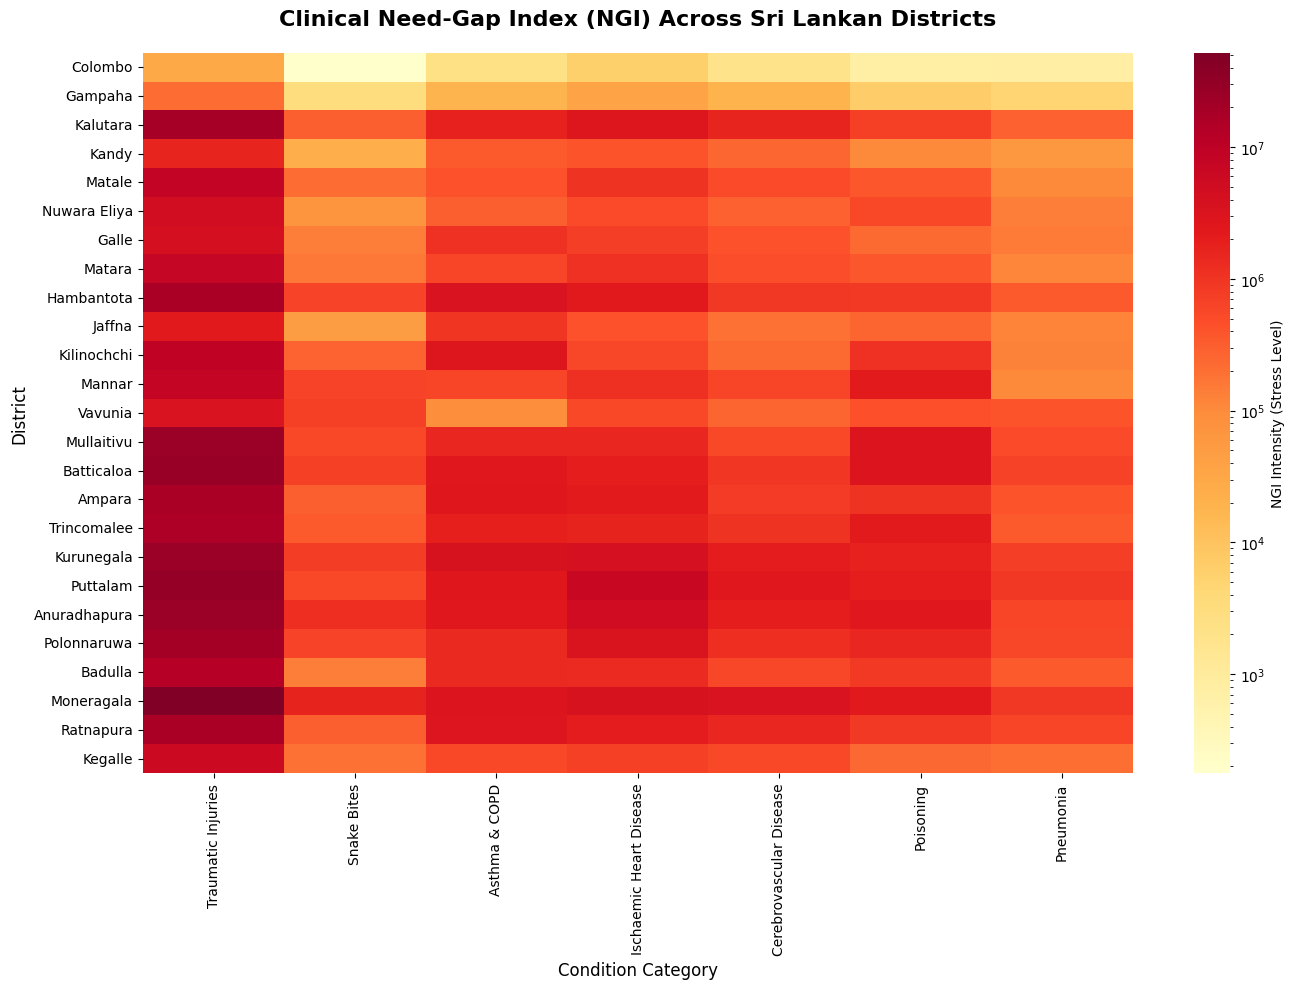

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

# 1. Load your updated data
df = pd.read_csv('Phase3_Research.csv')

# Mapping for clinical names
rename_map = {
    'NGI_Trauma': 'Traumatic Injuries',
    'NGI_Snake_Bites': 'Snake Bites',
    'NGI_Asthma': 'Asthma & COPD',
    'NGI_IHD': 'Ischaemic Heart Disease',
    'NGI_CV': 'Cerebrovascular Disease',
    'NGI_Poisoning': 'Poisoning',
    'NGI_Pneumonia': 'Pneumonia'
}

# Prepare data
heatmap_data = df.set_index('District')[list(rename_map.keys())]
heatmap_data.rename(columns=rename_map, inplace=True)

plt.figure(figsize=(14, 10))
# Heatmap with LogNorm to show detail across all districts
sns.heatmap(heatmap_data, annot=False, cmap='YlOrRd', norm=LogNorm(),
            cbar_kws={'label': 'NGI Intensity (Stress Level)'})

plt.title('Clinical Need-Gap Index (NGI) Across Sri Lankan Districts', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('District', fontsize=12)
plt.xlabel('Condition Category', fontsize=12)

plt.tight_layout()
plt.savefig('Step1_NGI_Heatmap.png', dpi=300)
plt.show()

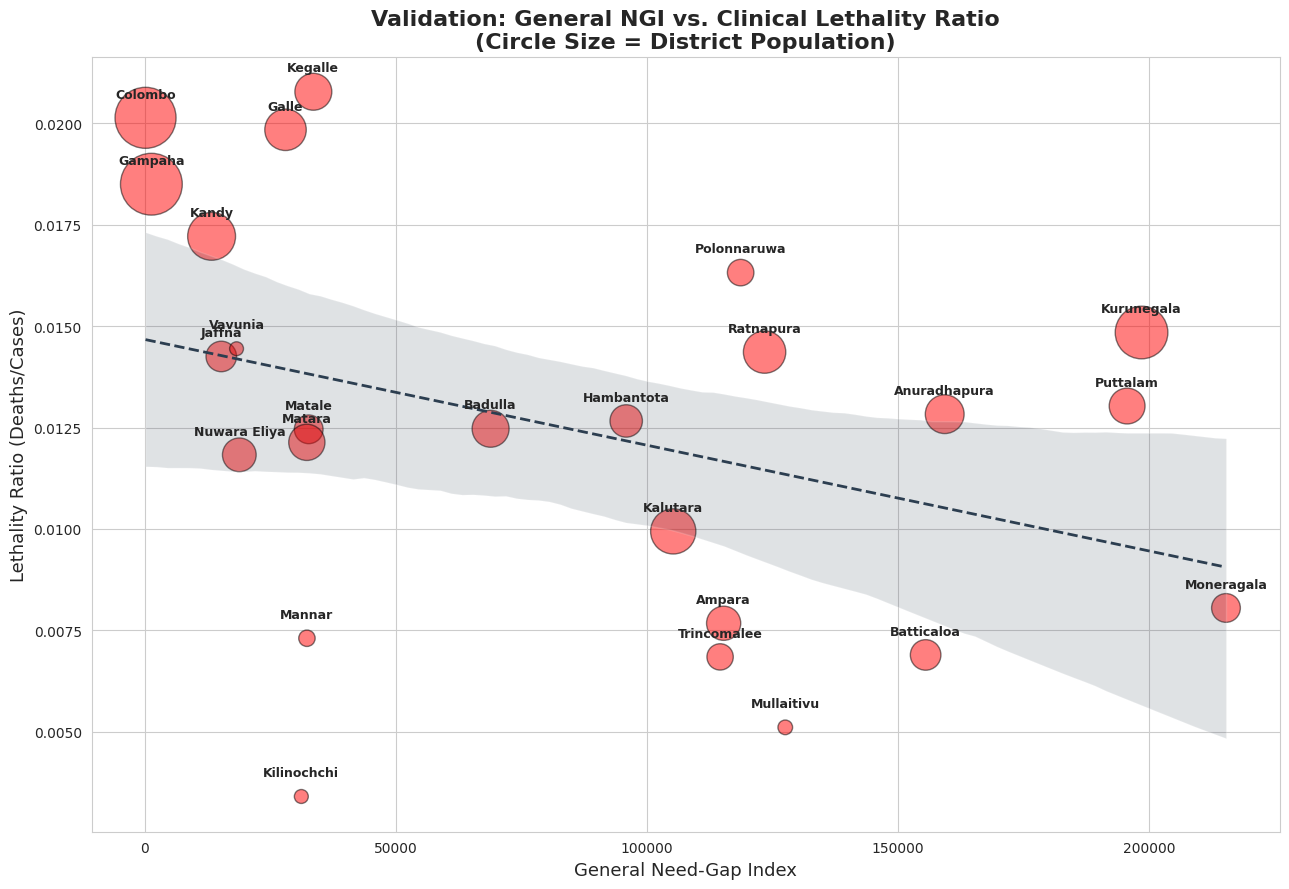

In [ ]:
plt.figure(figsize=(13, 9))
sns.set_style("whitegrid")

# We normalize population for bubble size (scaling it to look good on the plot)
size_scaling = (df['Population'] / df['Population'].min()) * 100

# Scatter plot where size = Population
scatter = plt.scatter(data=df, x='General_NGI', y='Lethality Ratio',
                      s=size_scaling, c='red', alpha=0.5, edgecolors='black')

# Add a trend line (Regression)
sns.regplot(data=df, x='General_NGI', y='Lethality Ratio',
            scatter=False, color='#2c3e50', line_kws={'lw':2, 'linestyle':'--'})

# Label the districts
for i, row in df.iterrows():
    plt.text(row['General_NGI'], row['Lethality Ratio'] + 0.0005,
             row['District'], fontsize=9, ha='center', fontweight='semibold')

plt.title('Validation: General NGI vs. Clinical Lethality Ratio\n(Circle Size = District Population)',
          fontsize=16, fontweight='bold')
plt.xlabel('General Need-Gap Index', fontsize=13)
plt.ylabel('Lethality Ratio (Deaths/Cases)', fontsize=13)

# If the X-axis is too wide, uncomment the next line to use Log Scale:
# plt.xscale('log')

plt.tight_layout()
plt.savefig('Step2_NGI_Validation_Population.png', dpi=300)
plt.show()

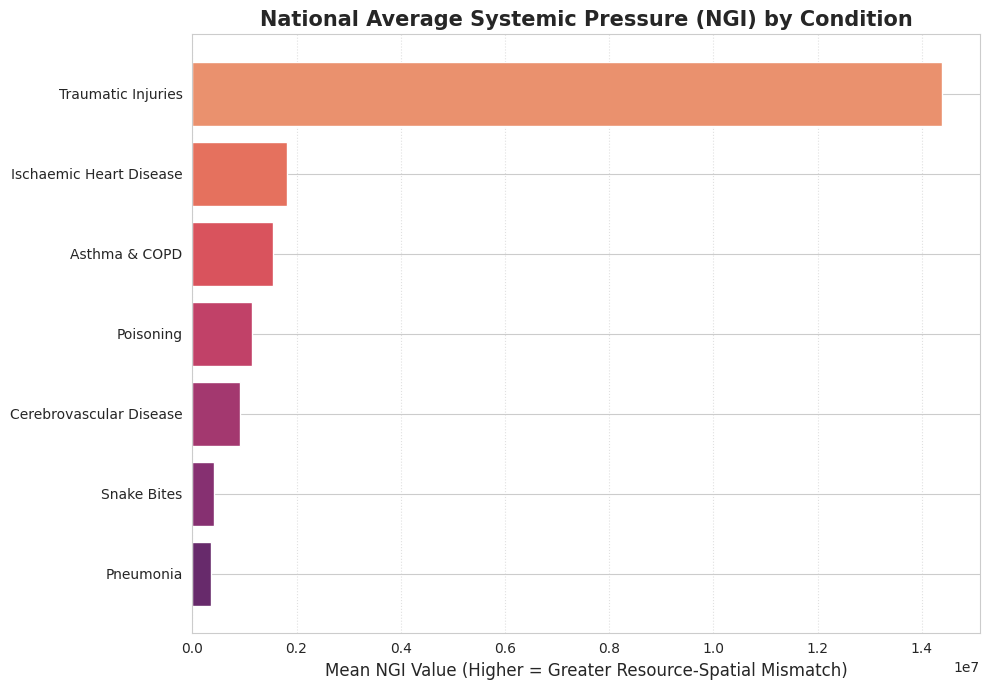

In [ ]:
# Calculate average NGI per condition across the country
avg_ngi = df[list(rename_map.keys())].mean().sort_values(ascending=False)
avg_ngi.index = [rename_map[col] for col in avg_ngi.index]

plt.figure(figsize=(10, 7))
colors = sns.color_palette("flare", len(avg_ngi))

# Horizontal bar chart
bars = plt.barh(avg_ngi.index, avg_ngi.values, color=colors)

plt.title('National Average Systemic Pressure (NGI) by Condition', fontsize=15, fontweight='bold')
plt.xlabel('Mean NGI Value (Higher = Greater Resource-Spatial Mismatch)', fontsize=12)
plt.gca().invert_yaxis() # Put the highest gap at the top
plt.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('Step3_Average_NGI_Priority.png', dpi=300)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. LOAD AND CLEAN DATA
df_raw = pd.read_csv('Phase3_Part2.csv')
# Assuming 'Gd' (Spatial Gap) is in your previous results CSV
df_spatial = pd.read_csv('Phase3_Research.csv')[['District', 'Gd']]
df = pd.merge(df_raw, df_spatial, on='District')

# Remove commas from large numbers and convert to float
cols_to_fix = ['Asthma_Tot_Cases', 'Isc_Heart_Tot_Cases', 'CV_Tot_Cases',
               'Poisoning_Tot_Cases', 'Pneumonia_Tot_Cases',
               'Tra_Injuries_Tot_Cases', 'Snake_Bites_Tot_Cases', 'Total Deaths']
for col in cols_to_fix:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '').astype(float)

# 2. NORMALIZATION (Step 1: Ingredients)
resource_cols = ['ETU Institutions', 'ICU_Beds', 'OT_Counts', 'Cardiologists',
                 'Radiologists', 'Neurologists', 'Paediatricians', 'Chest Physicans',
                 'General Physicians', 'Anaesthesiologists']
# Add Surgeon Sum
df['Surgeons_Sum'] = df['General Surgeons'] + df['Neuro Surgenons'] + df['Orthopaedic Surgens']
resource_cols.append('Surgeons_Sum')

for col in resource_cols:
    df[f'{col}_norm'] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

# 3. CALCULATE DISEASE RESOURCE SCORES (Step 2: Weighted Formulas)
df['Res_Trauma'] = (0.1*df['ETU Institutions_norm']) + (0.2*df['ICU_Beds_norm']) + (0.2*df['OT_Counts_norm']) + (0.35*df['Surgeons_Sum_norm']) + (0.15*df['Radiologists_norm'])
df['Res_IHD'] = (0.1*df['ETU Institutions_norm']) + (0.2*df['ICU_Beds_norm']) + (0.1*df['OT_Counts_norm']) + (0.45*df['Cardiologists_norm']) + (0.15*df['Radiologists_norm'])
df['Res_SnakeBite'] = (0.3*df['ETU Institutions_norm']) + (0.2*df['ICU_Beds_norm']) + (0.5*df['General Physicians_norm'])
# ... (Repeat for all 7 as per the weight table)

# 4. CALCULATE NGI (Step 4: Final Index)
# NGI = (Demand * Spatial Gap) / Normalized Supply
# Adding small epsilon to avoid division by zero
eps = 0.001
df['NGI_Trauma'] = (df['Tra_Injuries_Tot_Cases'] * df['Gd']) / (df['Res_Trauma'] + eps)
# ... (Calculate for all 7 diseases)

Analysis Complete. 7-Disease NGI calculated and figures saved.


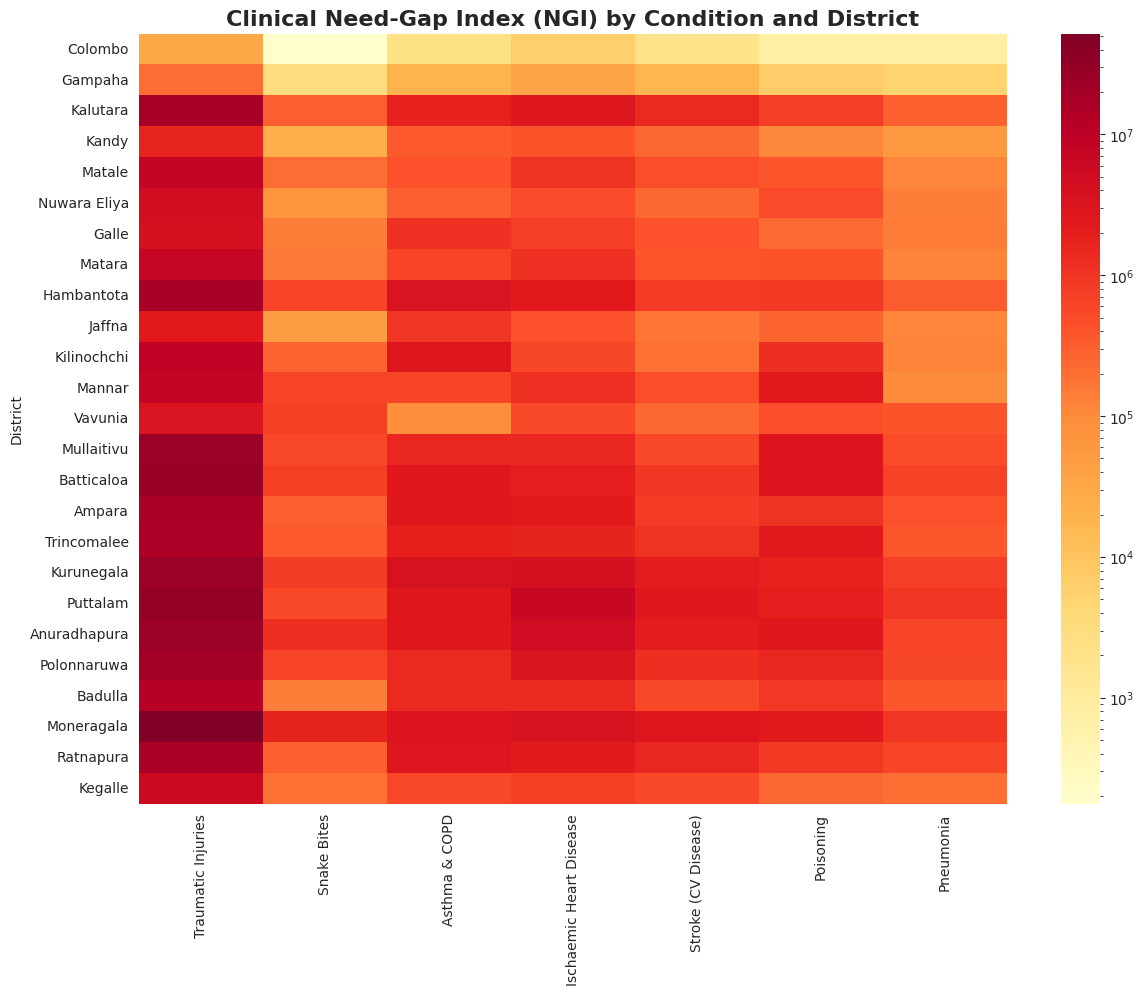

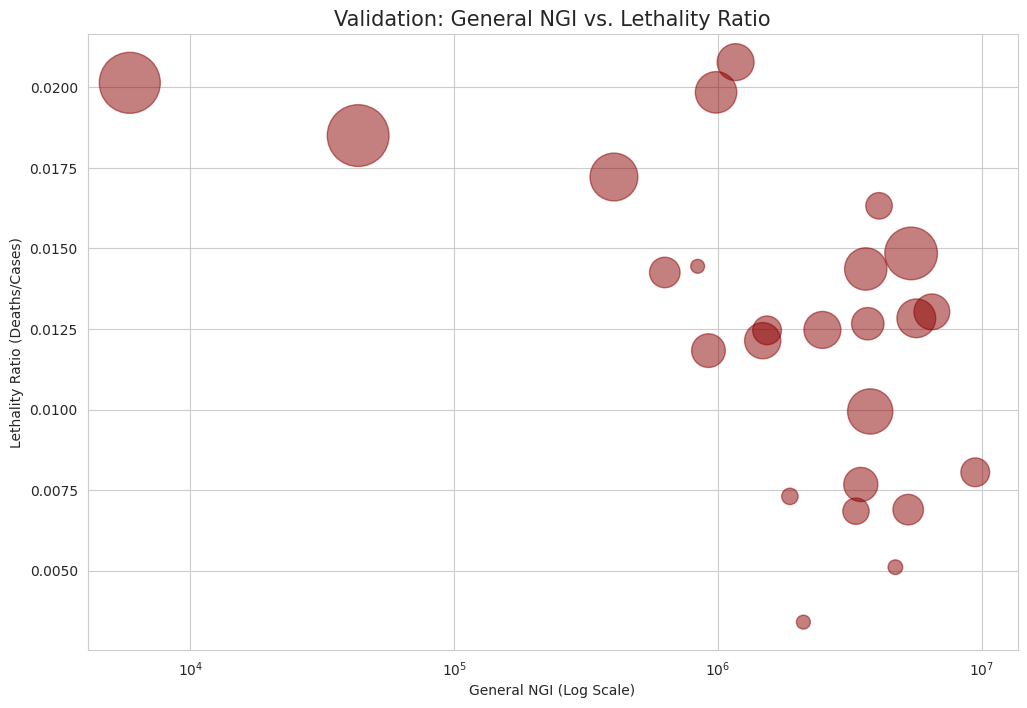

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# 1. LOAD AND MERGE DATA
# Phase3_Part2.csv has your raw hospital/case data
# Phase3_Research.csv has your Gd (Spatial Gap)
df_raw = pd.read_csv('Phase3_Part2.csv')
df_spatial = pd.read_csv('Phase3_Research.csv')[['District', 'Gd']]
df = pd.merge(df_raw, df_spatial, on='District')

# 2. DATA CLEANING
# Removing commas from numbers like "127,456" so Python can treat them as numbers
cols_to_clean = [
    'Asthma_Tot_Cases', 'Isc_Heart_Tot_Cases', 'CV_Tot_Cases',
    'Poisoning_Tot_Cases', 'Pneumonia_Tot_Cases',
    'Tra_Injuries_Tot_Cases', 'Snake_Bites_Tot_Cases', 'Total Deaths'
]
for col in cols_to_clean:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '').astype(float)

# 3. RESOURCE AGGREGATION & NORMALIZATION
# Summing the different types of surgeons for the Trauma score
df['Surgeons_Sum'] = df['General Surgeons'] + df['Neuro Surgenons'] + df['Orthopaedic Surgens']
# Creating a combined Physician group for Pneumonia
df['Chest_Gen_Phys'] = df['Chest Physicans'] + df['General Physicians']

# List of all ingredients to normalize (0 to 1 scale)
resource_cols = [
    'ETU Institutions', 'ICU_Beds', 'OT_Counts', 'Surgeons_Sum',
    'General Physicians', 'Chest Physicans', 'Paediatricians',
    'Cardiologists', 'Radiologists', 'Neurologists',
    'Anaesthesiologists', 'Chest_Gen_Phys'
]

for col in resource_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    # Normalize: (Value - Min) / (Max - Min)
    df[f'{col}_n'] = (df[col] - col_min) / (col_max - col_min)

# 4. CALCULATE CLINICAL RESOURCE SCORES (The Supply)
# All weights sum to 1.0 for each disease
df['Res_IHD'] = (0.1*df['ETU Institutions_n']) + (0.2*df['ICU_Beds_n']) + (0.1*df['OT_Counts_n']) + (0.45*df['Cardiologists_n']) + (0.15*df['Radiologists_n'])
df['Res_Stroke'] = (0.1*df['ETU Institutions_n']) + (0.2*df['ICU_Beds_n']) + (0.1*df['OT_Counts_n']) + (0.35*df['Neurologists_n']) + (0.25*df['Radiologists_n'])
df['Res_Trauma'] = (0.1*df['ETU Institutions_n']) + (0.2*df['ICU_Beds_n']) + (0.2*df['OT_Counts_n']) + (0.35*df['Surgeons_Sum_n']) + (0.15*df['Radiologists_n'])
df['Res_Asthma'] = (0.2*df['ETU Institutions_n']) + (0.1*df['ICU_Beds_n']) + (0.5*df['Chest Physicans_n']) + (0.2*df['Paediatricians_n'])
df['Res_SnakeBite'] = (0.3*df['ETU Institutions_n']) + (0.2*df['ICU_Beds_n']) + (0.5*df['General Physicians_n'])
df['Res_Poisoning'] = (0.2*df['ETU Institutions_n']) + (0.2*df['ICU_Beds_n']) + (0.3*df['Anaesthesiologists_n']) + (0.3*df['General Physicians_n'])
df['Res_Pneumonia'] = (0.2*df['ETU Institutions_n']) + (0.1*df['ICU_Beds_n']) + (0.4*df['Chest_Gen_Phys_n']) + (0.3*df['Radiologists_n'])

# 5. CALCULATE NGI (The Gap)
# Formula: (Cases * Gd) / Resource Score
eps = 0.0001 # Small value to prevent division by zero
df['NGI_IHD'] = (df['Isc_Heart_Tot_Cases'] * df['Gd']) / (df['Res_IHD'] + eps)
df['NGI_Stroke'] = (df['CV_Tot_Cases'] * df['Gd']) / (df['Res_Stroke'] + eps)
df['NGI_Trauma'] = (df['Tra_Injuries_Tot_Cases'] * df['Gd']) / (df['Res_Trauma'] + eps)
df['NGI_Asthma'] = (df['Asthma_Tot_Cases'] * df['Gd']) / (df['Res_Asthma'] + eps)
df['NGI_SnakeBite'] = (df['Snake_Bites_Tot_Cases'] * df['Gd']) / (df['Res_SnakeBite'] + eps)
df['NGI_Poisoning'] = (df['Poisoning_Tot_Cases'] * df['Gd']) / (df['Res_Poisoning'] + eps)
df['NGI_Pneumonia'] = (df['Pneumonia_Tot_Cases'] * df['Gd']) / (df['Res_Pneumonia'] + eps)

# Calculate General NGI (System-wide pressure)
df['General_NGI'] = df[['NGI_IHD', 'NGI_Stroke', 'NGI_Trauma', 'NGI_Asthma', 'NGI_SnakeBite', 'NGI_Poisoning', 'NGI_Pneumonia']].mean(axis=1)

# 6. EXPORT FINAL DATA
df.to_csv('Phase3_Final_Analysis.csv', index=False)

# 7. VISUALIZATIONS
# Map names for clean plot labels
rename_map = {
    'NGI_Trauma': 'Traumatic Injuries', 'NGI_SnakeBite': 'Snake Bites',
    'NGI_Asthma': 'Asthma & COPD', 'NGI_IHD': 'Ischaemic Heart Disease',
    'NGI_Stroke': 'Stroke (CV Disease)', 'NGI_Poisoning': 'Poisoning',
    'NGI_Pneumonia': 'Pneumonia'
}

# Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.set_index('District')[list(rename_map.keys())].rename(columns=rename_map),
            cmap='YlOrRd', norm=LogNorm())
plt.title('Clinical Need-Gap Index (NGI) by Condition and District', fontsize=16, fontweight='bold')
plt.savefig('Final_Heatmap.png', dpi=300)

# Validation Scatter Plot
plt.figure(figsize=(12, 8))
# Calculate Lethality Ratio for validation
df['Lethality_Ratio'] = df['Total Deaths'] / df[['Asthma_Tot_Cases', 'Isc_Heart_Tot_Cases', 'CV_Tot_Cases', 'Poisoning_Tot_Cases', 'Pneumonia_Tot_Cases', 'Tra_Injuries_Tot_Cases', 'Snake_Bites_Tot_Cases']].sum(axis=1)
size = (df['Population'] / df['Population'].min()) * 100
plt.scatter(df['General_NGI'], df['Lethality_Ratio'], s=size, alpha=0.5, c='darkred')
plt.xscale('log')
plt.title('Validation: General NGI vs. Lethality Ratio', fontsize=15)
plt.xlabel('General NGI (Log Scale)')
plt.ylabel('Lethality Ratio (Deaths/Cases)')
plt.savefig('Validation_Plot.png', dpi=300)

print("Analysis Complete. 7-Disease NGI calculated and figures saved.")